<a href="https://colab.research.google.com/github/motunbrighthub/emojis_log/blob/main/women_in_AI_sentiment_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install pandas nltk


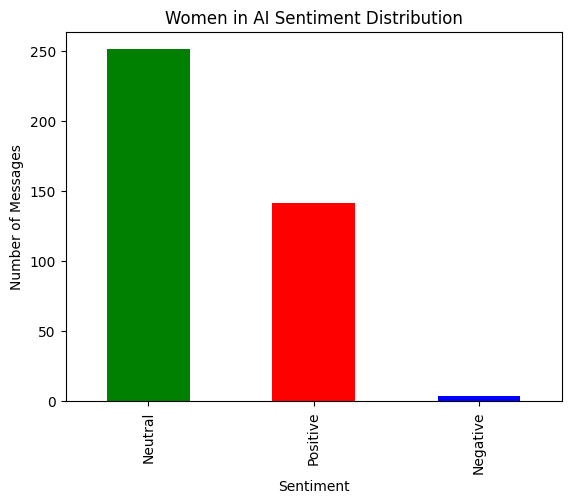

In [10]:
import re
import pandas as pd
from textblob import TextBlob
import matplotlib.pyplot as plt

# Load chat file
with open('/content/drive/MyDrive/_chat.txt', encoding='utf-8') as file:
    lines = file.readlines()

data = []
pattern = r'^\[(\d{2}/\d{2}/\d{4}), (\d{2}:\d{2}:\d{2})\] (.*?): (.*)'

for line in lines:
    match = re.match(pattern, line)
    if match:
        date, time, sender, message = match.groups()
        data.append([date, time, sender, message])

df = pd.DataFrame(data, columns=['Date', 'Time', 'Sender', 'Message'])




df['Polarity'] = df['Message'].apply(lambda msg: TextBlob(msg).sentiment.polarity)
df['Sentiment'] = df['Polarity'].apply(lambda score: 'Positive' if score > 0 else ('Negative' if score < 0 else 'Neutral'))

# Plot results
df['Sentiment'].value_counts().plot(kind='bar', color=['green', 'red', 'blue'], title='Women in AI Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Number of Messages')
plt.show()

#  Sentiment by person
# sent_by_person = df.groupby(['Sender', 'Sentiment']).size().unstack().fillna(0)
# print(sent_by_person)


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 12644 (\N{HANGUL FILLER}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


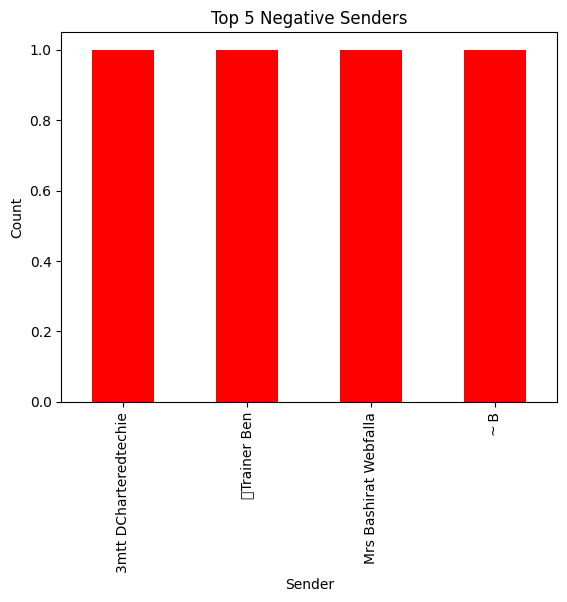

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 12644 (\N{HANGUL FILLER}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


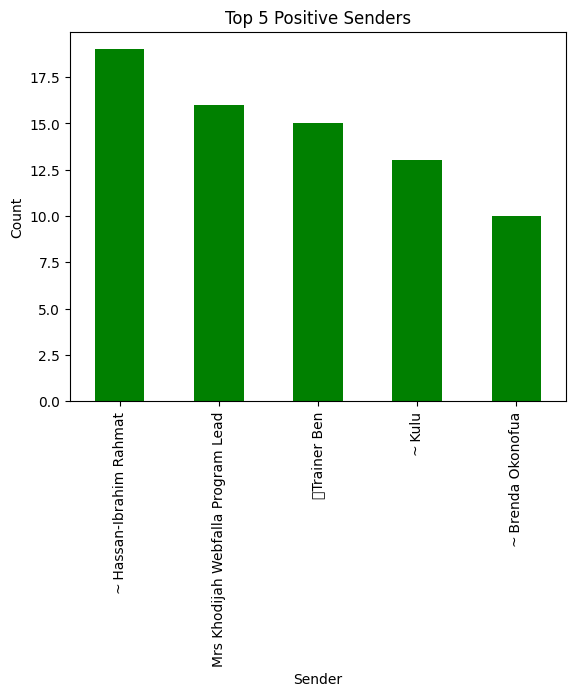

In [3]:
# Top 5 with most negative messages
df[df['Sentiment'] == 'Negative']['Sender'].value_counts().head(5).plot(kind='bar', color='red', title='Top 5 Negative Senders')
plt.ylabel('Count')
plt.show()

# Top 5 with most positive messages
df[df['Sentiment'] == 'Positive']['Sender'].value_counts().head(5).plot(kind='bar', color='green', title='Top 5 Positive Senders')
plt.ylabel('Count')
plt.show()


In [4]:
df.to_csv("whatsapp_sentiment_analysis_new.csv", index=False)